# Predicting NBA Championship Contenders from Mid-Season Team Snapshots Using Deep Learning

**Authors:** Shrujal Mogadati, Pranav Kaliaperumal, Disha Srinivasa  
**Course:** CSCI 5931, Deep Learning, Spring 2026

---

## How to Run This Notebook

### Step 1: Install required packages
Run the first code cell below. It will install everything you need.

### Step 2: Run all cells top to bottom
Click **Kernel > Restart & Run All** (or just Shift+Enter through each cell).

### Step 3: First run vs later runs
- **First run:** The data collection section will download data from the NBA API. This takes ~10-15 minutes due to API rate limits. Data gets saved to the `data/` folder.
- **Later runs:** The notebook detects saved data and loads from CSV files instead. Takes ~2 minutes total.

### What you'll see
- Charts showing data distributions
- Printed tables comparing model performance
- Visualizations of what the model learned

---

## 1. Imports & Setup
Install all required packages and import them.

In [3]:
# Install these once for this environment.

!pip install nba_api pandas numpy matplotlib seaborn torch scikit-learn tqdm -q

In [4]:
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# NBA data
from nba_api.stats.endpoints import (
    LeagueStandings,
    TeamEstimatedMetrics,
    LeagueDashTeamStats,
    LeagueDashPlayerStats,
)
from nba_api.stats.static import teams as nba_teams

# Modeling tools
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Project models
import sys
sys.path.append('src')
from nba_championship_prediction.modeling import MLPBaseline, AttentionModel

# Utilities
import os
import time
import warnings
from tqdm import tqdm

# Notebook settings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Use the GPU if we have one; CPU works fine here too.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("Setup complete!")

Using device: cpu
Setup complete!


## 2. Data Collection

We pull team and player stats from the NBA API for the last 20+ seasons (2003-04 through 2024-25).

**What we collect:**
- **Team stats:** wins, losses, offensive/defensive rating, pace, net rating, etc.
- **Player stats:** points, rebounds, assists, shooting percentages, etc. for each team's top 8 players by minutes played.

**Playoff outcomes (our labels):**
- 0 = Missed Playoffs
- 1 = First Round Exit
- 2 = Second Round Exit  
- 3 = Conference Finals
- 4 = Finals Appearance (lost in Finals)
- 5 = Champion

We also manually define the actual playoff results for each season since the API doesn't provide this directly.

In [6]:
# Playoff labels are entered by hand because nba_api does not include playoff depth.
# Teams missing from a season are treated as missed playoffs (0); 5 means champion.

playoff_results = {
    "2003-04": {
        "DET": 5, "LAL": 4, "MIN": 3, "IND": 3,
        "SAS": 2, "SAC": 2, "NJN": 2, "MIL": 2,
        "MEM": 1, "HOU": 1, "DAL": 1, "MIA": 1,
        "DEN": 1, "BOS": 1, "NOH": 1, "NYK": 1,
    },
    "2004-05": {
        "SAS": 5, "DET": 4, "MIA": 3, "PHX": 3,
        "IND": 2, "WAS": 2, "DAL": 2, "SEA": 2,
        "CHI": 1, "BOS": 1, "NJN": 1, "PHI": 1,
        "HOU": 1, "MEM": 1, "DEN": 1, "SAC": 1,
    },
    "2005-06": {
        "MIA": 5, "DAL": 4, "DET": 3, "LAC": 3,
        "CLE": 2, "NJN": 2, "PHX": 2, "SAS": 2,
        "CHI": 1, "MIL": 1, "IND": 1, "WAS": 1,
        "MEM": 1, "SAC": 1, "LAL": 1, "DEN": 1,
    },
    "2006-07": {
        "SAS": 5, "CLE": 4, "DET": 3, "UTA": 3,
        "CHI": 2, "NJN": 2, "PHX": 2, "GSW": 2,
        "TOR": 1, "WAS": 1, "ORL": 1, "MIA": 1,
        "HOU": 1, "LAL": 1, "DAL": 1, "DEN": 1,
    },
    "2007-08": {
        "BOS": 5, "LAL": 4, "DET": 3, "SAS": 3,
        "CLE": 2, "ORL": 2, "UTA": 2, "NOH": 2,
        "ATL": 1, "PHI": 1, "TOR": 1, "WAS": 1,
        "PHX": 1, "DAL": 1, "HOU": 1, "DEN": 1,
    },
    "2008-09": {
        "LAL": 5, "ORL": 4, "CLE": 3, "DEN": 3,
        "BOS": 2, "ATL": 2, "HOU": 2, "DAL": 2,
        "CHI": 1, "MIA": 1, "DET": 1, "PHI": 1,
        "SAS": 1, "POR": 1, "NOH": 1, "UTA": 1,
    },
    "2009-10": {
        "LAL": 5, "BOS": 4, "ORL": 3, "PHX": 3,
        "CLE": 2, "ATL": 2, "UTA": 2, "SAS": 2,
        "MIA": 1, "MIL": 1, "CHI": 1, "CHA": 1,
        "DAL": 1, "POR": 1, "OKC": 1, "DEN": 1,
    },
    "2010-11": {
        "DAL": 5, "MIA": 4, "CHI": 3, "OKC": 3,
        "ATL": 2, "BOS": 2, "LAL": 2, "MEM": 2,
        "PHI": 1, "NYK": 1, "ORL": 1, "IND": 1,
        "POR": 1, "DEN": 1, "NOH": 1, "SAS": 1,
    },
    "2011-12": {
        "MIA": 5, "OKC": 4, "BOS": 3, "SAS": 3,
        "IND": 2, "PHI": 2, "LAC": 2, "LAL": 2,
        "NYK": 1, "ATL": 1, "ORL": 1, "CHI": 1,
        "DAL": 1, "MEM": 1, "DEN": 1, "UTA": 1,
    },
    "2012-13": {
        "MIA": 5, "SAS": 4, "IND": 3, "MEM": 3,
        "NYK": 2, "CHI": 2, "GSW": 2, "OKC": 2,
        "BOS": 1, "MIL": 1, "ATL": 1, "BKN": 1,
        "LAC": 1, "DEN": 1, "HOU": 1, "LAL": 1,
    },
    "2013-14": {
        "SAS": 5, "MIA": 4, "IND": 3, "OKC": 3,
        "BKN": 2, "WAS": 2, "POR": 2, "LAC": 2,
        "TOR": 1, "CHI": 1, "CHA": 1, "ATL": 1,
        "HOU": 1, "MEM": 1, "DAL": 1, "GSW": 1,
    },
    "2014-15": {
        "GSW": 5, "CLE": 4, "ATL": 3, "HOU": 3,
        "CHI": 2, "WAS": 2, "LAC": 2, "MEM": 2,
        "TOR": 1, "MIL": 1, "BOS": 1, "BKN": 1,
        "SAS": 1, "DAL": 1, "POR": 1, "NOH": 1,
    },
    "2015-16": {
        "CLE": 5, "GSW": 4, "OKC": 3, "TOR": 3,
        "MIA": 2, "ATL": 2, "SAS": 2, "POR": 2,
        "CHA": 1, "IND": 1, "BOS": 1, "DET": 1,
        "LAC": 1, "MEM": 1, "DAL": 1, "HOU": 1,
    },
    "2016-17": {
        "GSW": 5, "CLE": 4, "BOS": 3, "SAS": 3,
        "WAS": 2, "TOR": 2, "HOU": 2, "UTA": 2,
        "MIL": 1, "ATL": 1, "CHI": 1, "IND": 1,
        "LAC": 1, "MEM": 1, "OKC": 1, "POR": 1,
    },
    "2017-18": {
        "GSW": 5, "CLE": 4, "BOS": 3, "HOU": 3,
        "TOR": 2, "PHI": 2, "NOP": 2, "UTA": 2,
        "IND": 1, "MIL": 1, "MIA": 1, "WAS": 1,
        "SAS": 1, "MIN": 1, "OKC": 1, "POR": 1,
    },
    "2018-19": {
        "TOR": 5, "GSW": 4, "MIL": 3, "POR": 3,
        "PHI": 2, "BOS": 2, "DEN": 2, "HOU": 2,
        "BKN": 1, "ORL": 1, "IND": 1, "DET": 1,
        "OKC": 1, "SAS": 1, "UTA": 1, "LAC": 1,
    },
    "2019-20": {
        "LAL": 5, "MIA": 4, "BOS": 3, "DEN": 3,
        "TOR": 2, "MIL": 2, "LAC": 2, "HOU": 2,
        "BKN": 1, "PHI": 1, "IND": 1, "ORL": 1,
        "OKC": 1, "DAL": 1, "POR": 1, "UTA": 1,
    },
    "2020-21": {
        "MIL": 5, "PHX": 4, "ATL": 3, "LAC": 3,
        "PHI": 2, "BKN": 2, "UTA": 2, "DEN": 2,
        "NYK": 1, "BOS": 1, "MIA": 1, "WAS": 1,
        "LAL": 1, "POR": 1, "DAL": 1, "MEM": 1,
    },
    "2021-22": {
        "GSW": 5, "BOS": 4, "MIA": 3, "DAL": 3,
        "PHI": 2, "MIL": 2, "MEM": 2, "PHX": 2,
        "TOR": 1, "CHI": 1, "BKN": 1, "ATL": 1,
        "NOP": 1, "MIN": 1, "UTA": 1, "DEN": 1,
    },
    "2022-23": {
        "DEN": 5, "MIA": 4, "BOS": 3, "LAL": 3,
        "PHI": 2, "NYK": 2, "PHX": 2, "GSW": 2,
        "CLE": 1, "ATL": 1, "MIL": 1, "BKN": 1,
        "MEM": 1, "SAC": 1, "LAC": 1, "MIN": 1,
    },
    "2023-24": {
        "BOS": 5, "DAL": 4, "IND": 3, "MIN": 3,
        "NYK": 2, "CLE": 2, "DEN": 2, "OKC": 2,
        "PHI": 1, "MIL": 1, "ORL": 1, "MIA": 1,
        "LAL": 1, "NOP": 1, "LAC": 1, "PHX": 1,
    },
}

seasons = list(playoff_results.keys())
print(f"We have playoff data for {len(seasons)} seasons: {seasons[0]} through {seasons[-1]}")

We have playoff data for 21 seasons: 2003-04 through 2023-24


In [7]:
# Standardize team codes so older franchise names match the playoff labels.
# Some teams moved or changed abbreviations during this date range.

abbrev_fixes = {
    "NJN": "BKN",
    "NOH": "NOP",
    "NOK": "NOP",
    "SEA": "OKC",
    "CHA": "CHO",
    "CHO": "CHA",
    "VAN": "MEM",
    "GOS": "GSW",
}

def fix_abbrev(abbrev, season):
    """
    Normalize team abbreviation so we can match API data to our playoff results.
    Some teams changed names/cities, so the same franchise has different codes.
    """
    # Keep Charlotte's Bobcats/Hornets codes aligned.
    if abbrev == "CHO":
        return "CHA"
    if abbrev in abbrev_fixes:
        return abbrev_fixes[abbrev]
    return abbrev

# Build a reverse lookup for labels that use older abbreviations.
def get_playoff_label(team_abbrev, season):
    """
    Given a team abbreviation and season, return their playoff outcome (0-5).
    Returns 0 (missed playoffs) if the team isn't in our playoff dictionary for that season.
    """
    results = playoff_results.get(season, {})

    if team_abbrev in results:
        return results[team_abbrev]

    # Try older team codes too.
    variants = {
        "BKN": ["NJN", "BKN"],
        "NOP": ["NOH", "NOK", "NOP"],
        "OKC": ["SEA", "OKC"],
        "CHA": ["CHA", "CHO", "CHH"],
        "MEM": ["VAN", "MEM"],
    }

    for current, old_names in variants.items():
        if team_abbrev == current or team_abbrev in old_names:
            for name in old_names:
                if name in results:
                    return results[name]

    # If a team is not listed, it missed the playoffs.
    return 0

print("Team abbreviation mapping ready!")

Team abbreviation mapping ready!


In [8]:
# Pull basic team stats for each season.

team_stats_file = "data/raw/team_stats_all_seasons.csv"

if os.path.exists(team_stats_file):
    print("Loading team stats from saved file...")
    all_team_stats = pd.read_csv(team_stats_file)
    print(f"Loaded {len(all_team_stats)} team-season records")
else:
    print("Downloading team stats from NBA API (this takes a few minutes)...")
    all_team_stats_list = []

    for season in tqdm(seasons, desc="Fetching team stats"):
        try:
            stats = LeagueDashTeamStats(
                season=season,
                per_mode_detailed="PerGame",
                season_type_all_star="Regular Season"
            )
            df = stats.get_data_frames()[0]
            df["SEASON"] = season
            all_team_stats_list.append(df)
            time.sleep(1)
        except Exception as e:
            print(f"  Error fetching {season}: {e}")
            time.sleep(3)

    all_team_stats = pd.concat(all_team_stats_list, ignore_index=True)
    os.makedirs("data/raw", exist_ok=True)
    all_team_stats.to_csv(team_stats_file, index=False)
    print(f"Saved {len(all_team_stats)} team-season records to {team_stats_file}")

# Add team abbreviations.
# The API doesn't always return abbreviations, so we map TEAM_ID -> abbreviation
# using the nba_api static teams list
nba_team_list = nba_teams.get_teams()
team_id_to_abbrev = {t["id"]: t["abbreviation"] for t in nba_team_list}

if "TEAM_ABBREVIATION" not in all_team_stats.columns:
    all_team_stats["TEAM_ABBREVIATION"] = all_team_stats["TEAM_ID"].map(team_id_to_abbrev)
    print("Added TEAM_ABBREVIATION column from static team list")
else:
    print("TEAM_ABBREVIATION column already exists")

print(f"Columns: {list(all_team_stats.columns[:10])}... ({all_team_stats.shape[1]} total)")
all_team_stats.head()

Loading team stats from saved file...
Loaded 629 team-season records
Added TEAM_ABBREVIATION column from static team list
Columns: ['TEAM_ID', 'TEAM_NAME', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT']... (56 total)


,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,...,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,SEASON,TEAM_ABBREVIATION
0,1610612737,Atlanta Hawks,82,28,54,0.341,48.5,34.5,79.6,0.433,...,26,17,12,15,23,15,15,26,2003-04,ATL
1,1610612738,Boston Celtics,82,36,46,0.439,48.1,34.7,78.2,0.443,...,24,2,25,12,24,24,8,19,2003-04,BOS
2,1610612741,Chicago Bulls,82,23,59,0.280,48.4,34.1,82.4,0.414,...,23,13,15,22,28,15,26,28,2003-04,CHI
3,1610612739,Cleveland Cavaliers,82,35,47,0.427,48.4,35.6,82.4,0.433,...,15,23,3,19,15,24,14,22,2003-04,CLE
4,1610612742,Dallas Mavericks,82,52,30,0.634,48.3,40.5,88.2,0.459,...,1,15,10,7,3,15,1,6,2003-04,DAL


In [9]:
# Pull the advanced team stats we use later.

advanced_stats_file = "data/raw/team_advanced_stats_all_seasons.csv"

if os.path.exists(advanced_stats_file):
    print("Loading advanced team stats from saved file...")
    all_advanced_stats = pd.read_csv(advanced_stats_file)
    print(f"Loaded {len(all_advanced_stats)} records")
else:
    print("Downloading advanced team stats from NBA API...")
    all_advanced_list = []

    for season in tqdm(seasons, desc="Fetching advanced stats"):
        try:
            stats = TeamEstimatedMetrics(
                season=season,
                season_type="Regular Season"
            )
            df = stats.get_data_frames()[0]
            df["SEASON"] = season
            all_advanced_list.append(df)
            time.sleep(1)
        except Exception as e:
            print(f"  Error fetching {season}: {e}")
            time.sleep(3)

    all_advanced_stats = pd.concat(all_advanced_list, ignore_index=True)
    all_advanced_stats.to_csv(advanced_stats_file, index=False)
    print(f"Saved {len(all_advanced_stats)} records to {advanced_stats_file}")

# Do not merge again if this cell was already run.
if "E_OFF_RATING" not in all_team_stats.columns:
    # Keep the estimated advanced stats and merge keys so duplicate columns do not pile up.
    adv_cols = ["TEAM_ID", "SEASON"] + [c for c in all_advanced_stats.columns if c.startswith("E_")]
    all_team_stats = all_team_stats.merge(
        all_advanced_stats[adv_cols],
        on=["TEAM_ID", "SEASON"],
        how="left"
    )
    print(f"Merged! Team stats now has {all_team_stats.shape[1]} columns")
else:
    print("Advanced stats already merged, skipping.")

print(f"Advanced stats: {[c for c in all_team_stats.columns if c.startswith('E_')]}")
print(f"TEAM_ABBREVIATION column exists: {'TEAM_ABBREVIATION' in all_team_stats.columns}")

Loading advanced team stats from saved file...
Loaded 629 records
Merged! Team stats now has 74 columns
Advanced stats: ['E_OFF_RATING', 'E_DEF_RATING', 'E_NET_RATING', 'E_PACE', 'E_AST_RATIO', 'E_OREB_PCT', 'E_DREB_PCT', 'E_REB_PCT', 'E_TM_TOV_PCT', 'E_OFF_RATING_RANK', 'E_DEF_RATING_RANK', 'E_NET_RATING_RANK', 'E_AST_RATIO_RANK', 'E_OREB_PCT_RANK', 'E_DREB_PCT_RANK', 'E_REB_PCT_RANK', 'E_TM_TOV_PCT_RANK', 'E_PACE_RANK']
TEAM_ABBREVIATION column exists: True


In [10]:
# Pull player stats for each season.

player_stats_file = "data/raw/player_stats_all_seasons.csv"

if os.path.exists(player_stats_file):
    print("Loading player stats from saved file...")
    all_player_stats = pd.read_csv(player_stats_file)
    print(f"Loaded {len(all_player_stats)} player-season records")
else:
    print("Downloading player stats from NBA API (this takes several minutes)...")
    all_player_stats_list = []

    for season in tqdm(seasons, desc="Fetching player stats"):
        try:
            stats = LeagueDashPlayerStats(
                season=season,
                per_mode_detailed="PerGame",
                season_type_all_star="Regular Season"
            )
            df = stats.get_data_frames()[0]
            df["SEASON"] = season
            all_player_stats_list.append(df)
            time.sleep(1)
        except Exception as e:
            print(f"  Error fetching {season}: {e}")
            time.sleep(3)

    all_player_stats = pd.concat(all_player_stats_list, ignore_index=True)
    all_player_stats.to_csv(player_stats_file, index=False)
    print(f"Saved {len(all_player_stats)} player-season records to {player_stats_file}")

all_player_stats.head()

Loading player stats from saved file...
Loaded 10350 player-season records


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT,SEASON
0,243,Aaron McKie,Aaron,1610612755,PHI,31.0,75,30,45,0.400,...,232,79,145,217,145,235,19,139,1,2003-04
1,1425,Aaron Williams,Aaron,1610612751,NJN,32.0,72,39,33,0.542,...,92,79,211,234,217,178,19,215,1,2003-04
2,1502,Adonal Foyle,Adonal,1610612744,GSW,29.0,44,21,23,0.477,...,290,79,343,338,270,146,19,289,1,2003-04
3,1559,Adrian Griffin,Adrian,1610612745,HOU,29.0,19,13,6,0.684,...,394,79,433,375,408,235,19,413,1,2003-04
4,1733,Al Harrington,Al,1610612754,IND,24.0,79,58,21,0.734,...,31,79,83,122,97,47,19,94,1,2003-04


## 3. Exploratory Data Analysis (EDA)

Before building any models, let's understand our data:
- How many teams fall into each playoff category?
- Which stats are most different between champions and non-playoff teams?
- What does the data look like overall?

In [12]:
# Label each team-season with its playoff result.

all_team_stats["TEAM_ABBREVIATION_CLEAN"] = all_team_stats["TEAM_ABBREVIATION"].apply(
    lambda x: fix_abbrev(x, "")
)

all_team_stats["PLAYOFF_RESULT"] = all_team_stats.apply(
    lambda row: get_playoff_label(row["TEAM_ABBREVIATION_CLEAN"], row["SEASON"]),
    axis=1
)

# Labels for charts.
label_names = {
    0: "Missed Playoffs",
    1: "First Round Exit",
    2: "Second Round Exit",
    3: "Conference Finals",
    4: "Finals Loss",
    5: "Champion"
}
all_team_stats["PLAYOFF_LABEL"] = all_team_stats["PLAYOFF_RESULT"].map(label_names)

print("Distribution of playoff outcomes across all seasons:")
print(all_team_stats["PLAYOFF_LABEL"].value_counts().sort_index())

Distribution of playoff outcomes across all seasons:
PLAYOFF_LABEL
Champion              21
Conference Finals     42
Finals Loss           21
First Round Exit     168
Missed Playoffs      293
Second Round Exit     84
Name: count, dtype: int64


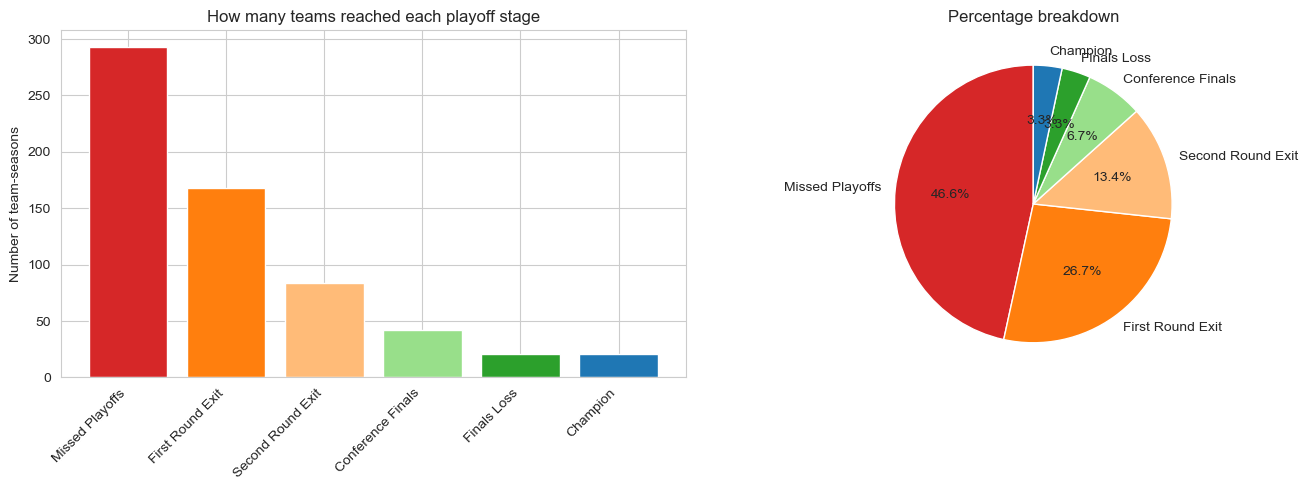


Key takeaway: Only 21 champions out of 629 total team-seasons
This is heavily imbalanced - we'll use class weights to handle this.


In [13]:
# Chart 1: class balance.
# Most teams fall into the early classes, so the labels are pretty imbalanced.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ["Missed Playoffs", "First Round Exit", "Second Round Exit",
         "Conference Finals", "Finals Loss", "Champion"]
colors = ["#d62728", "#ff7f0e", "#ffbb78", "#98df8a", "#2ca02c", "#1f77b4"]

counts = all_team_stats["PLAYOFF_LABEL"].value_counts()
counts = counts.reindex(order)
axes[0].bar(range(len(order)), counts.values, color=colors)
axes[0].set_xticks(range(len(order)))
axes[0].set_xticklabels(order, rotation=45, ha='right')
axes[0].set_ylabel("Number of team-seasons")
axes[0].set_title("How many teams reached each playoff stage")

axes[1].pie(counts.values, labels=order, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title("Percentage breakdown")

plt.tight_layout()
plt.show()

print(f"\nKey takeaway: Only {counts.get('Champion', 0)} champions out of {len(all_team_stats)} total team-seasons")
print("This is heavily imbalanced - we'll use class weights to handle this.")

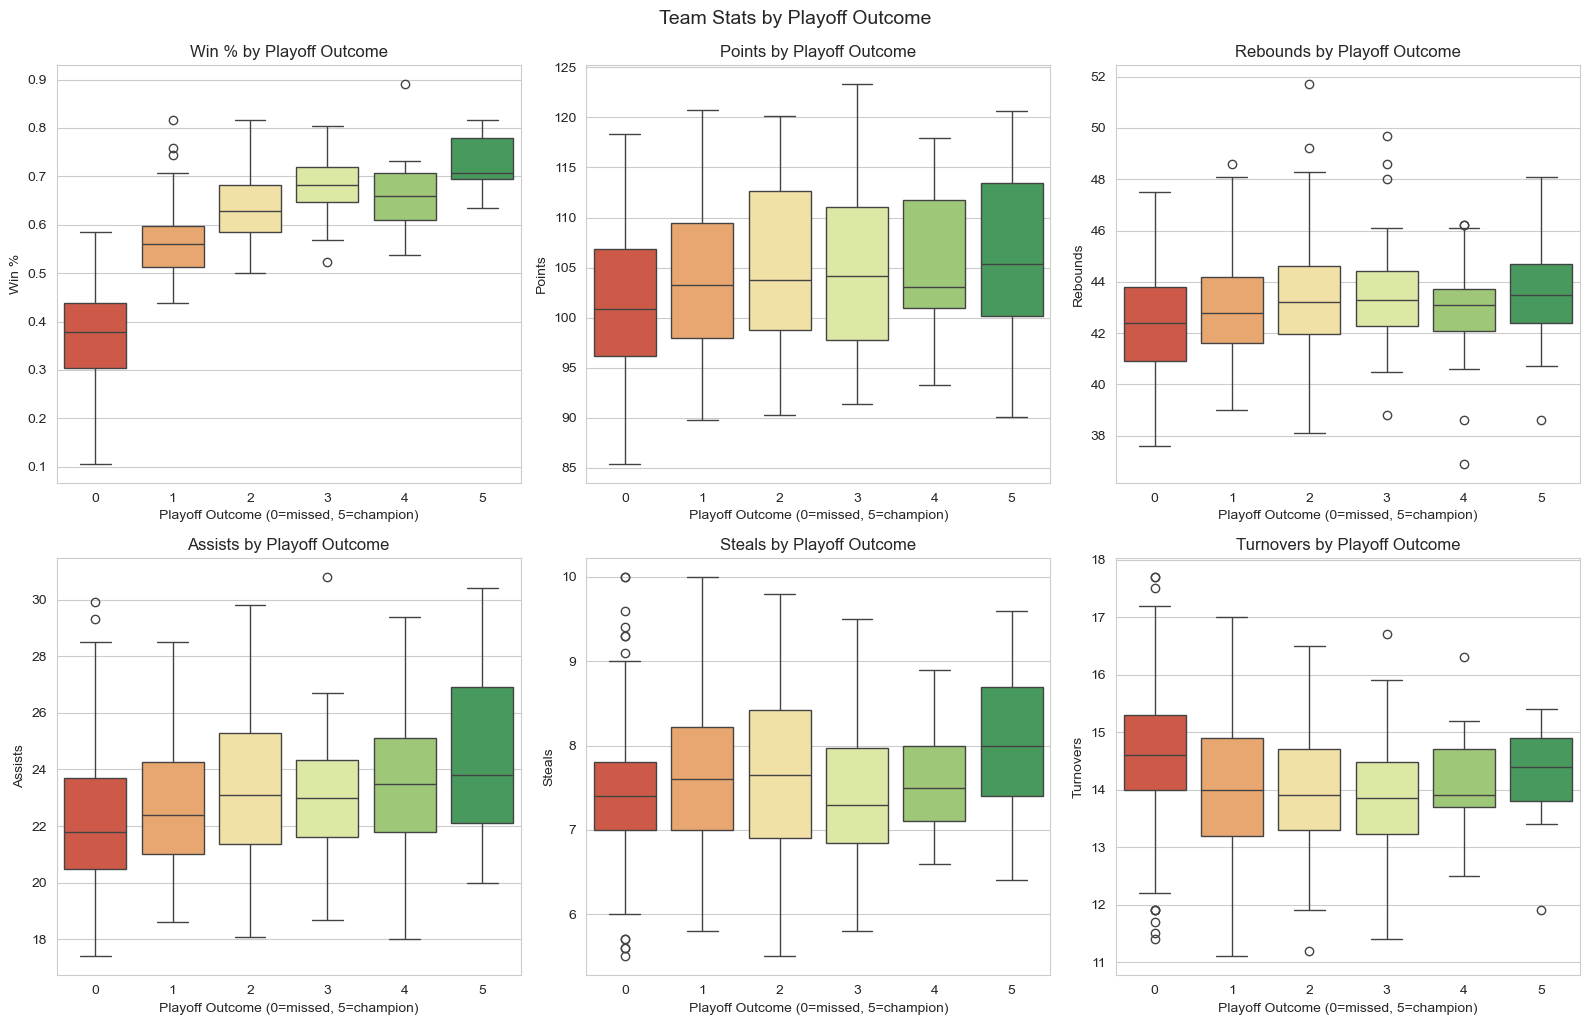

Key insight: Win percentage is the strongest predictor (no surprise).
Champions tend to have better stats across the board.


In [14]:
# Chart 2: how key stats change by playoff outcome.

key_stats = ["W_PCT", "PTS", "REB", "AST", "STL", "TOV"]
stat_labels = ["Win %", "Points", "Rebounds", "Assists", "Steals", "Turnovers"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (stat, label) in enumerate(zip(key_stats, stat_labels)):
    if stat in all_team_stats.columns:
        sns.boxplot(
            data=all_team_stats,
            x="PLAYOFF_RESULT",
            y=stat,
            ax=axes[i],
            palette="RdYlGn"
        )
        axes[i].set_xlabel("Playoff Outcome (0=missed, 5=champion)")
        axes[i].set_ylabel(label)
        axes[i].set_title(f"{label} by Playoff Outcome")

plt.tight_layout()
plt.suptitle("Team Stats by Playoff Outcome", y=1.02, fontsize=14)
plt.show()

print("Key insight: Win percentage is the strongest predictor (no surprise).")
print("Champions tend to have better stats across the board.")

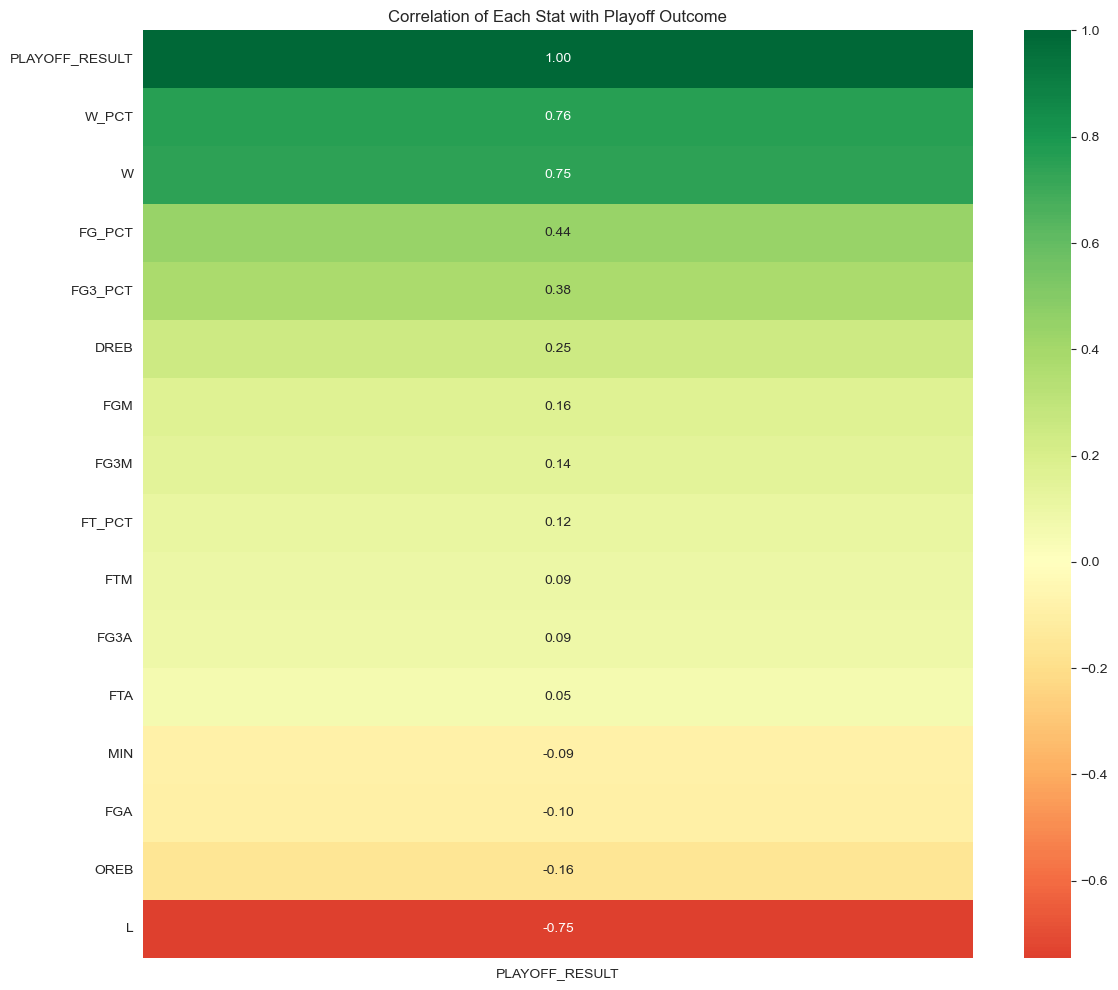

Stats with high positive correlation = good predictor of deeper playoff runs


In [15]:
# Chart 3: stat correlations.

numeric_cols = all_team_stats.select_dtypes(include=[np.number]).columns
# Leave IDs and game counts out of the correlation view.
interesting = [c for c in numeric_cols if c not in ["TEAM_ID", "GP", "CFID", "CFPARAMS", "PLAYOFF_RESULT"]]

# Show the top 15 so the chart stays readable.
if len(interesting) > 15:
    interesting = interesting[:15]

corr_matrix = all_team_stats[interesting + ["PLAYOFF_RESULT"]].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix[["PLAYOFF_RESULT"]].sort_values("PLAYOFF_RESULT", ascending=False),
    annot=True, cmap="RdYlGn", center=0, fmt=".2f"
)
plt.title("Correlation of Each Stat with Playoff Outcome")
plt.tight_layout()
plt.show()

print("Stats with high positive correlation = good predictor of deeper playoff runs")

## 4. Feature Engineering

Now we build our actual feature set. For each team-season, we create:

1. **Team-level features (~15):** Win %, points, rebounds, assists, steals, blocks, turnovers, field goal %, 3-point %, free throw %, plus/minus, etc.

2. **Player-level features (top 8 players x 10 stats = 80):** For each team's top 8 players by minutes played: points, rebounds, assists, steals, blocks, turnovers, FG%, 3P%, FT%, minutes.

3. **Label:** Playoff outcome (0-5)

In [17]:
# Pick the feature columns.

# Team-level stats: basic stats plus advanced metrics.
team_feature_cols = [
    "W_PCT",
    "PTS",
    "REB",
    "AST",
    "STL",
    "BLK",
    "TOV",
    "FG_PCT",
    "FG3_PCT",
    "FT_PCT",
    "PLUS_MINUS",
    "W",
    "L",
    # Advanced ratings and pace come from TeamEstimatedMetrics.
    "E_OFF_RATING",
    "E_DEF_RATING",
    "E_NET_RATING",
    "E_PACE",
]

# Context features we calculate from season/team history.
contextual_feature_cols = [
    "CONF_STRENGTH",
    "ROSTER_CONTINUITY",
]

# Player stats for each rotation player.
player_feature_cols = [
    "PTS",
    "REB",
    "AST",
    "STL",
    "BLK",
    "TOV",
    "FG_PCT",
    "FG3_PCT",
    "FT_PCT",
    "MIN",
    "PER_APPROX",
]

# Use the top eight players by minutes played.
NUM_PLAYERS = 8

print(f"Team features: {len(team_feature_cols)} basic/advanced + {len(contextual_feature_cols)} contextual")
print(f"Player features per player: {len(player_feature_cols)} (including PER)")
print(f"Total player features: {NUM_PLAYERS} x {len(player_feature_cols)} = {NUM_PLAYERS * len(player_feature_cols)}")
total = len(team_feature_cols) + len(contextual_feature_cols) + NUM_PLAYERS * len(player_feature_cols)
print(f"Total features per team-season: {total}")

Team features: 17 basic/advanced + 2 contextual
Player features per player: 11 (including PER)
Total player features: 8 x 11 = 88
Total features per team-season: 107


In [18]:
# Use a lightweight PER-style score, not the official formula.
# Approximate PER = (PTS + REB + AST + STL + BLK - TOV) / MIN

def compute_approximate_per(player_row):
    """Simplified PER: positive contributions minus turnovers, divided by minutes."""
    minutes = player_row.get("MIN", 0)
    if minutes == 0 or pd.isna(minutes):
        return 0
    positive = (player_row.get("PTS", 0) + player_row.get("REB", 0) +
                player_row.get("AST", 0) + player_row.get("STL", 0) +
                player_row.get("BLK", 0))
    negative = player_row.get("TOV", 0)
    return (positive - negative) / minutes

all_player_stats["PER_APPROX"] = all_player_stats.apply(compute_approximate_per, axis=1)
print(f"Computed approximate PER for {len(all_player_stats)} player-season records")
print(f"Average PER: {all_player_stats['PER_APPROX'].mean():.2f}")
print(f"PER range: {all_player_stats['PER_APPROX'].min():.2f} to {all_player_stats['PER_APPROX'].max():.2f}")

Computed approximate PER for 10350 player-season records
Average PER: 0.64
PER range: -0.77 to 6.00


In [19]:
# Roster continuity estimates how many top rotation players stayed from last season.

all_player_stats["TEAM_ABBREVIATION_CLEAN"] = all_player_stats["TEAM_ABBREVIATION"].apply(
    lambda x: fix_abbrev(x, "")
)

def compute_roster_continuity(team_id, season, prev_season, player_data, num_players=8):
    """
    What fraction of this team's top 8 players were also on this team last season?
    Returns a value between 0 and 1. (1 = all 8 players returned, 0 = completely new roster)
    """
    current = player_data[
        (player_data["TEAM_ID"] == team_id) & (player_data["SEASON"] == season)
    ].sort_values("MIN", ascending=False).head(num_players)

    if len(current) == 0:
        return 0.5  # default if no data

    prev = player_data[
        (player_data["TEAM_ID"] == team_id) & (player_data["SEASON"] == prev_season)
    ]

    if len(prev) == 0:
        return 0.5  # first season in our data, use default

    # Count how many current top players were on last year's roster.
    prev_player_ids = set(prev["PLAYER_ID"].values)
    returning = sum(1 for pid in current["PLAYER_ID"].values if pid in prev_player_ids)

    return returning / len(current)

print("Roster continuity function ready!")

# Conference strength is the average win percentage of teams in the same conference.

# These conference groups are mostly stable for the seasons we use.
eastern_conf = ["BOS", "BKN", "NJN", "NYK", "PHI", "TOR",
                "CHI", "CLE", "DET", "IND", "MIL",
                "ATL", "CHA", "CHO", "MIA", "ORL", "WAS"]
western_conf = ["DAL", "HOU", "MEM", "NOP", "NOH", "NOK", "SAS",
                "DEN", "MIN", "OKC", "SEA", "POR", "UTA",
                "GSW", "LAC", "LAL", "PHX", "SAC"]

def get_conference(team_abbrev):
    """Return 'East' or 'West' for a given team abbreviation."""
    clean = fix_abbrev(team_abbrev, "")
    if clean in [fix_abbrev(t, "") for t in eastern_conf]:
        return "East"
    return "West"

print("Conference strength function ready!")

Roster continuity function ready!
Conference strength function ready!


In [20]:
# Build the feature matrix.
# For each team in each season, combine:
# - Team stats (basic + advanced)
# - Contextual features (conference strength, roster continuity)
# - Top 8 player stats (including PER)

processed_file = "data/processed/features_v2.csv"

if os.path.exists(processed_file):
    print("Loading processed features from saved file...")
    features_df = pd.read_csv(processed_file)
    print(f"Loaded {len(features_df)} team-season records with {features_df.shape[1]} columns")
else:
    print("Building feature matrix (this takes a minute)...")
    rows = []

    all_team_stats["CONFERENCE"] = all_team_stats["TEAM_ABBREVIATION"].apply(get_conference)

    # Build a lookup for previous season (e.g., "2004-05" -> "2003-04")
    season_pairs = {seasons[i]: seasons[i-1] for i in range(1, len(seasons))}

    for season in tqdm(seasons, desc="Processing seasons"):
        season_teams = all_team_stats[all_team_stats["SEASON"] == season]
        season_players = all_player_stats[all_player_stats["SEASON"] == season]

        # Use average W_PCT within each conference as conference strength.
        conf_strength = {}
        for conf in ["East", "West"]:
            conf_teams = season_teams[season_teams["CONFERENCE"] == conf]
            conf_strength[conf] = conf_teams["W_PCT"].mean() if len(conf_teams) > 0 else 0.5

        for _, team_row in season_teams.iterrows():
            team_abbrev = fix_abbrev(team_row["TEAM_ABBREVIATION"], season)
            team_id = team_row["TEAM_ID"]
            team_conf = team_row["CONFERENCE"]

            team_players = season_players[
                season_players["TEAM_ID"] == team_id
            ].sort_values("MIN", ascending=False)
            top_players = team_players.head(NUM_PLAYERS)

            row = {"SEASON": season, "TEAM": team_abbrev}

            # Team features.
            for col in team_feature_cols:
                val = team_row.get(col, 0)
                row[f"TEAM_{col}"] = val if pd.notna(val) else 0

            # Context features.
            row["CONF_STRENGTH"] = conf_strength.get(team_conf, 0.5)

            prev_season = season_pairs.get(season, None)
            if prev_season:
                row["ROSTER_CONTINUITY"] = compute_roster_continuity(
                    team_id, season, prev_season, all_player_stats, NUM_PLAYERS
                )
            else:
                row["ROSTER_CONTINUITY"] = 0.5  # default for first season

            # Player features for the top rotation players.
            for p_idx in range(NUM_PLAYERS):
                if p_idx < len(top_players):
                    player = top_players.iloc[p_idx]
                    for col in player_feature_cols:
                        val = player.get(col, 0)
                        row[f"P{p_idx+1}_{col}"] = val if pd.notna(val) else 0
                else:
                    for col in player_feature_cols:
                        row[f"P{p_idx+1}_{col}"] = 0

            row["PLAYOFF_RESULT"] = get_playoff_label(team_abbrev, season)

            rows.append(row)

    features_df = pd.DataFrame(rows)
    features_df = features_df.fillna(0)

    os.makedirs("data/processed", exist_ok=True)
    features_df.to_csv(processed_file, index=False)
    print(f"Saved {len(features_df)} rows x {features_df.shape[1]} columns to {processed_file}")

print(f"\nDataset shape: {features_df.shape}")
print(f"Seasons: {features_df['SEASON'].nunique()}")
print(f"Label distribution:\n{features_df['PLAYOFF_RESULT'].value_counts().sort_index()}")
features_df.head()

Building feature matrix (this takes a minute)...


Processing seasons: 100%|███████████████████████| 21/21 [00:00<00:00, 27.19it/s]


Saved 629 rows x 110 columns to data/processed/features_v2.csv

Dataset shape: (629, 110)
Seasons: 21
Label distribution:
PLAYOFF_RESULT
0    293
1    168
2     84
3     42
4     21
5     21
Name: count, dtype: int64


,SEASON,TEAM,TEAM_W_PCT,TEAM_PTS,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_FG_PCT,...,P8_AST,P8_STL,P8_BLK,P8_TOV,P8_FG_PCT,P8_FG3_PCT,P8_FT_PCT,P8_MIN,P8_PER_APPROX,PLAYOFF_RESULT
0,2003-04,ATL,0.341,92.8,42.7,20.1,7.6,5.0,16.5,0.433,...,2.7,0.6,0.0,1.2,0.386,0.150,0.779,17.8,0.421348,0
1,2003-04,BOS,0.439,95.3,40.1,20.5,9.4,4.0,16.2,0.443,...,0.3,0.5,0.8,1.2,0.488,0.000,0.663,17.5,0.691429,1
2,2003-04,CHI,0.280,89.7,43.5,21.9,8.0,4.8,16.1,0.414,...,1.1,0.6,0.2,0.9,0.482,0.200,0.651,20.1,0.482587,0
3,2003-04,CLE,0.427,92.9,45.6,22.0,7.1,6.5,14.8,0.433,...,1.1,0.4,0.3,0.8,0.391,0.105,0.783,19.5,0.379487,0
4,2003-04,DAL,0.634,105.2,45.3,23.9,8.0,5.3,12.2,0.459,...,0.8,0.8,0.2,0.5,0.380,0.303,0.841,15.6,0.583333,1


In [21]:
# Set up X/y and remember where team features stop and player features start.

team_cols = [f"TEAM_{col}" for col in team_feature_cols]

context_cols = contextual_feature_cols

player_cols = [f"P{p+1}_{col}" for p in range(NUM_PLAYERS) for col in player_feature_cols]

# Check which columns actually exist in the dataframe
# (some advanced stats might be missing for older seasons)
team_cols = [c for c in team_cols if c in features_df.columns]
context_cols = [c for c in context_cols if c in features_df.columns]
player_cols = [c for c in player_cols if c in features_df.columns]

all_feature_cols = team_cols + context_cols + player_cols

X = features_df[all_feature_cols].values.astype(np.float32)
y = features_df["PLAYOFF_RESULT"].values.astype(np.int64)
seasons_array = features_df["SEASON"].values

# The model needs this split before it separates team and player inputs.
num_team_features = len(team_cols) + len(context_cols)

# This lets us reshape the flat player columns back into players by stats.
num_player_stats = len(player_cols) // NUM_PLAYERS

print(f"X shape: {X.shape} (teams x features)")
print(f"y shape: {y.shape}")
print(f"Team + contextual features: {num_team_features} ({len(team_cols)} team + {len(context_cols)} context)")
print(f"Player features: {len(player_cols)} ({NUM_PLAYERS} players x {num_player_stats} stats)")
print(f"Total: {num_team_features + len(player_cols)} features")
print(f"Sanity check: {num_team_features} + {NUM_PLAYERS} x {num_player_stats} = {num_team_features + NUM_PLAYERS * num_player_stats}")
print(f"Unique labels: {np.unique(y)}")

X shape: (629, 107) (teams x features)
y shape: (629,)
Team + contextual features: 19 (17 team + 2 context)
Player features: 88 (8 players x 11 stats)
Total: 107 features
Sanity check: 19 + 8 x 11 = 107
Unique labels: [0 1 2 3 4 5]


## 5. Baseline Models

Before our fancy attention model, we test simpler approaches:
1. **Logistic Regression** - a classic, simple classifier
2. **Random Forest** - an ensemble of decision trees
3. **MLP Baseline** - a basic neural network (fully connected layers only)

We use **leave-one-season-out cross validation**: train on all seasons except one, test on the held-out season. Repeat for every season. This ensures the model never sees future data.

In [23]:
# Evaluation helpers.

def compute_class_weights(y_train):
    """
    Compute weights for each class so the model pays more attention
    to rare classes (like Champion) and less to common ones (like Missed Playoffs).

    Without this, the model would just predict "Missed Playoffs" for everything
    and get ~47% accuracy, which is useless.
    """
    classes, counts = np.unique(y_train, return_counts=True)
    total = len(y_train)
    weights = {}
    for cls, count in zip(classes, counts):
        weights[cls] = total / (len(classes) * count)
    return weights

def top_k_accuracy(y_true, y_proba, k=2):
    """
    Top-k accuracy: did the correct answer appear in the model's top k guesses?

    For example, if the model says "80% Champion, 15% Finals, 5% Conference Finals"
    and the true answer is "Finals", that's correct for top-2 accuracy
    (Finals was the model's #2 guess).
    """
    correct = 0
    for true, proba in zip(y_true, y_proba):
        top_k_preds = np.argsort(proba)[-k:]
        if true in top_k_preds:
            correct += 1
    return correct / len(y_true)

def evaluate_predictions(y_true, y_pred, y_proba=None):
    """
    Calculate all our evaluation metrics in one go.
    Returns a dictionary with accuracy, macro F1, and top-2 accuracy.
    """
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    if y_proba is not None:
        results["top2_accuracy"] = top_k_accuracy(y_true, y_proba, k=2)
    return results

print("Evaluation helper functions ready!")

Evaluation helper functions ready!


In [24]:
# Leave-one-season-out cross validation for the sklearn baselines.
# Train on all seasons except one, predict on the held-out season, repeat

def run_sklearn_baseline(model_class, model_params, X, y, seasons_array):
    """
    Run leave-one-season-out CV for a scikit-learn model.
    Returns predictions and probabilities for all samples.
    """
    unique_seasons = np.unique(seasons_array)
    all_preds = np.zeros(len(y), dtype=np.int64)
    all_proba = np.zeros((len(y), 6))

    for test_season in unique_seasons:
        train_mask = seasons_array != test_season
        test_mask = seasons_array == test_season

        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]

        # Normalize using only the training fold.
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Compute class weights to handle imbalance
        weights = compute_class_weights(y_train)

        model = model_class(**model_params, class_weight=weights)
        model.fit(X_train_scaled, y_train)

        all_preds[test_mask] = model.predict(X_test_scaled)
        all_proba[test_mask] = model.predict_proba(X_test_scaled)

    return all_preds, all_proba

# Run logistic regression.
print("Running Logistic Regression...")
lr_preds, lr_proba = run_sklearn_baseline(
    LogisticRegression,
    {"max_iter": 1000, "random_state": 42},
    X, y, seasons_array
)
lr_results = evaluate_predictions(y, lr_preds, lr_proba)
print(f"  Accuracy: {lr_results['accuracy']:.3f}")
print(f"  F1 (macro): {lr_results['f1_macro']:.3f}")
print(f"  Top-2 Accuracy: {lr_results['top2_accuracy']:.3f}")

# Run random forest.
print("\nRunning Random Forest...")
rf_preds, rf_proba = run_sklearn_baseline(
    RandomForestClassifier,
    {"n_estimators": 200, "random_state": 42, "max_depth": 10},
    X, y, seasons_array
)
rf_results = evaluate_predictions(y, rf_preds, rf_proba)
print(f"  Accuracy: {rf_results['accuracy']:.3f}")
print(f"  F1 (macro): {rf_results['f1_macro']:.3f}")
print(f"  Top-2 Accuracy: {rf_results['top2_accuracy']:.3f}")

Running Logistic Regression...
  Accuracy: 0.623
  F1 (macro): 0.406
  Top-2 Accuracy: 0.808

Running Random Forest...
  Accuracy: 0.680
  F1 (macro): 0.358
  Top-2 Accuracy: 0.839


In [25]:
# MLP baseline.
# It uses fully connected layers only, so there is no attention yet.

def train_mlp_one_fold(X_train, y_train, X_test, y_test, num_team_features, epochs=100, lr=0.001):
    """
    Train the MLP baseline on one fold of leave-one-season-out CV.
    """
    # Normalize using only the training fold.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_t = torch.FloatTensor(X_train_scaled).to(device)
    y_train_t = torch.LongTensor(y_train).to(device)
    X_test_t = torch.FloatTensor(X_test_scaled).to(device)

    team_train = X_train_t[:, :num_team_features]
    player_train = X_train_t[:, num_team_features:]
    team_test = X_test_t[:, :num_team_features]
    player_test = X_test_t[:, num_team_features:]

    input_size = X_train.shape[1]
    model = MLPBaseline(input_size=input_size, num_classes=6).to(device)

    # Loss function with class weights (to handle imbalance)
    weights_dict = compute_class_weights(y_train)
    weight_tensor = torch.FloatTensor([weights_dict.get(i, 1.0) for i in range(6)]).to(device)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(team_train, player_train)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        outputs = model(team_test, player_test)
        proba = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()

    return preds, proba

# Run the MLP with leave-one-season-out validation.
print("Running MLP Baseline...")
unique_seasons = np.unique(seasons_array)
mlp_preds = np.zeros(len(y), dtype=np.int64)
mlp_proba = np.zeros((len(y), 6))
num_team_features = len(team_cols)

for test_season in tqdm(unique_seasons, desc="MLP CV"):
    train_mask = seasons_array != test_season
    test_mask = seasons_array == test_season

    preds, proba = train_mlp_one_fold(
        X[train_mask], y[train_mask],
        X[test_mask], y[test_mask],
        num_team_features=num_team_features,
        epochs=150, lr=0.001
    )
    mlp_preds[test_mask] = preds
    mlp_proba[test_mask] = proba

mlp_results = evaluate_predictions(y, mlp_preds, mlp_proba)
print(f"\nMLP Baseline Results:")
print(f"  Accuracy: {mlp_results['accuracy']:.3f}")
print(f"  F1 (macro): {mlp_results['f1_macro']:.3f}")
print(f"  Top-2 Accuracy: {mlp_results['top2_accuracy']:.3f}")

Running MLP Baseline...


MLP CV: 100%|███████████████████████████████████| 21/21 [00:03<00:00,  6.75it/s]


MLP Baseline Results:
  Accuracy: 0.607
  F1 (macro): 0.352
  Top-2 Accuracy: 0.822


## 6. Attention Model

This is the main model from our proposal. Instead of treating all player stats as a flat vector:

1. Each player's stats go through a **shared embedding network** (learns a compact summary of each player)
2. **Attention pooling** figures out which players matter most and combines them
3. The combined player representation is joined with team stats for the final prediction

The key advantage: the model can learn that a star player's stats matter more than a bench player's.

In [27]:
# Train the attention model.

def train_attention_one_fold(X_train, y_train, X_test, y_test,
                              num_team_features, num_player_stats,
                              num_players=8, epochs=200, lr=0.001):
    """
    Train the attention model on one fold.
    Returns predictions, probabilities, and the attention weights
    (so we can visualize which players the model thinks are important).
    """
    # Normalize using only the training fold.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_t = torch.FloatTensor(X_train_scaled).to(device)
    y_train_t = torch.LongTensor(y_train).to(device)
    X_test_t = torch.FloatTensor(X_test_scaled).to(device)

    team_train = X_train_t[:, :num_team_features]
    player_train = X_train_t[:, num_team_features:]
    team_test = X_test_t[:, :num_team_features]
    player_test = X_test_t[:, num_team_features:]

    # Figure out how many stats each player has in this fold.
    actual_player_stats = player_train.shape[1] // num_players

    # Trim extra columns if they do not divide evenly by num_players.
    trimmed_size = actual_player_stats * num_players
    player_train = player_train[:, :trimmed_size]
    player_test = player_test[:, :trimmed_size]

    model = AttentionModel(
        team_stat_size=num_team_features,
        player_stat_size=actual_player_stats,
        num_players=num_players,
        embedding_size=32,
        num_classes=6
    ).to(device)

    # Loss with class weights.
    weights_dict = compute_class_weights(y_train)
    weight_tensor = torch.FloatTensor([weights_dict.get(i, 1.0) for i in range(6)]).to(device)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        logits, _ = model(team_train, player_train)
        loss = criterion(logits, y_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        logits, attn_weights = model(team_test, player_test)
        proba = torch.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        attn_weights = attn_weights.cpu().numpy()

    return preds, proba, attn_weights, model

# Run the attention model with leave-one-season-out validation.
print("Running Attention Model (this takes a bit longer)...")
attn_preds = np.zeros(len(y), dtype=np.int64)
attn_proba = np.zeros((len(y), 6))
all_attn_weights = np.zeros((len(y), NUM_PLAYERS))
# Keep the last trained model for the attention plot.
last_model = None

total_features = X.shape[1]
player_feature_count = total_features - num_team_features
print(f"Total features: {total_features}, Team: {num_team_features}, Player: {player_feature_count}")
print(f"Player features per player: {player_feature_count // NUM_PLAYERS}")

for test_season in tqdm(unique_seasons, desc="Attention CV"):
    train_mask = seasons_array != test_season
    test_mask = seasons_array == test_season

    preds, proba, attn_w, model = train_attention_one_fold(
        X[train_mask], y[train_mask],
        X[test_mask], y[test_mask],
        num_team_features=num_team_features,
        num_player_stats=num_player_stats,
        num_players=NUM_PLAYERS,
        epochs=200, lr=0.001
    )
    attn_preds[test_mask] = preds
    attn_proba[test_mask] = proba
    all_attn_weights[test_mask] = attn_w
    last_model = model

attn_results = evaluate_predictions(y, attn_preds, attn_proba)
print(f"\nAttention Model Results:")
print(f"  Accuracy: {attn_results['accuracy']:.3f}")
print(f"  F1 (macro): {attn_results['f1_macro']:.3f}")
print(f"  Top-2 Accuracy: {attn_results['top2_accuracy']:.3f}")

Running Attention Model (this takes a bit longer)...
Total features: 107, Team: 17, Player: 90
Player features per player: 11


Attention CV: 100%|█████████████████████████████| 21/21 [00:10<00:00,  1.98it/s]


Attention Model Results:
  Accuracy: 0.618
  F1 (macro): 0.394
  Top-2 Accuracy: 0.831


## 7. Evaluation & Visualization

Now let's compare all models side by side and create visualizations:
1. **Model comparison table** - which model performed best?
2. **Confusion matrices** - what types of mistakes does each model make?
3. **Attention weight visualization** - which player positions does the model focus on?
4. **t-SNE visualization** - do championship teams cluster together in the learned embedding space?
5. **Ethical considerations** - does the model favor large/small market teams?

In [29]:
# Compare the models side by side.

results_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "MLP Baseline", "Attention Model"],
    "Accuracy": [lr_results["accuracy"], rf_results["accuracy"],
                 mlp_results["accuracy"], attn_results["accuracy"]],
    "F1 (Macro)": [lr_results["f1_macro"], rf_results["f1_macro"],
                   mlp_results["f1_macro"], attn_results["f1_macro"]],
    "Top-2 Accuracy": [lr_results["top2_accuracy"], rf_results["top2_accuracy"],
                       mlp_results["top2_accuracy"], attn_results["top2_accuracy"]],
})

for col in ["Accuracy", "F1 (Macro)", "Top-2 Accuracy"]:
    results_table[col] = results_table[col].apply(lambda x: f"{x:.1%}")

print("=" * 60)
print("MODEL COMPARISON (Leave-One-Season-Out Cross Validation)")
print("=" * 60)
print(results_table.to_string(index=False))
print("=" * 60)

MODEL COMPARISON (Leave-One-Season-Out Cross Validation)
              Model Accuracy F1 (Macro) Top-2 Accuracy
Logistic Regression    62.3%      40.6%          80.8%
      Random Forest    68.0%      35.8%          83.9%
       MLP Baseline    60.7%      35.2%          82.2%
    Attention Model    61.8%      39.4%          83.1%


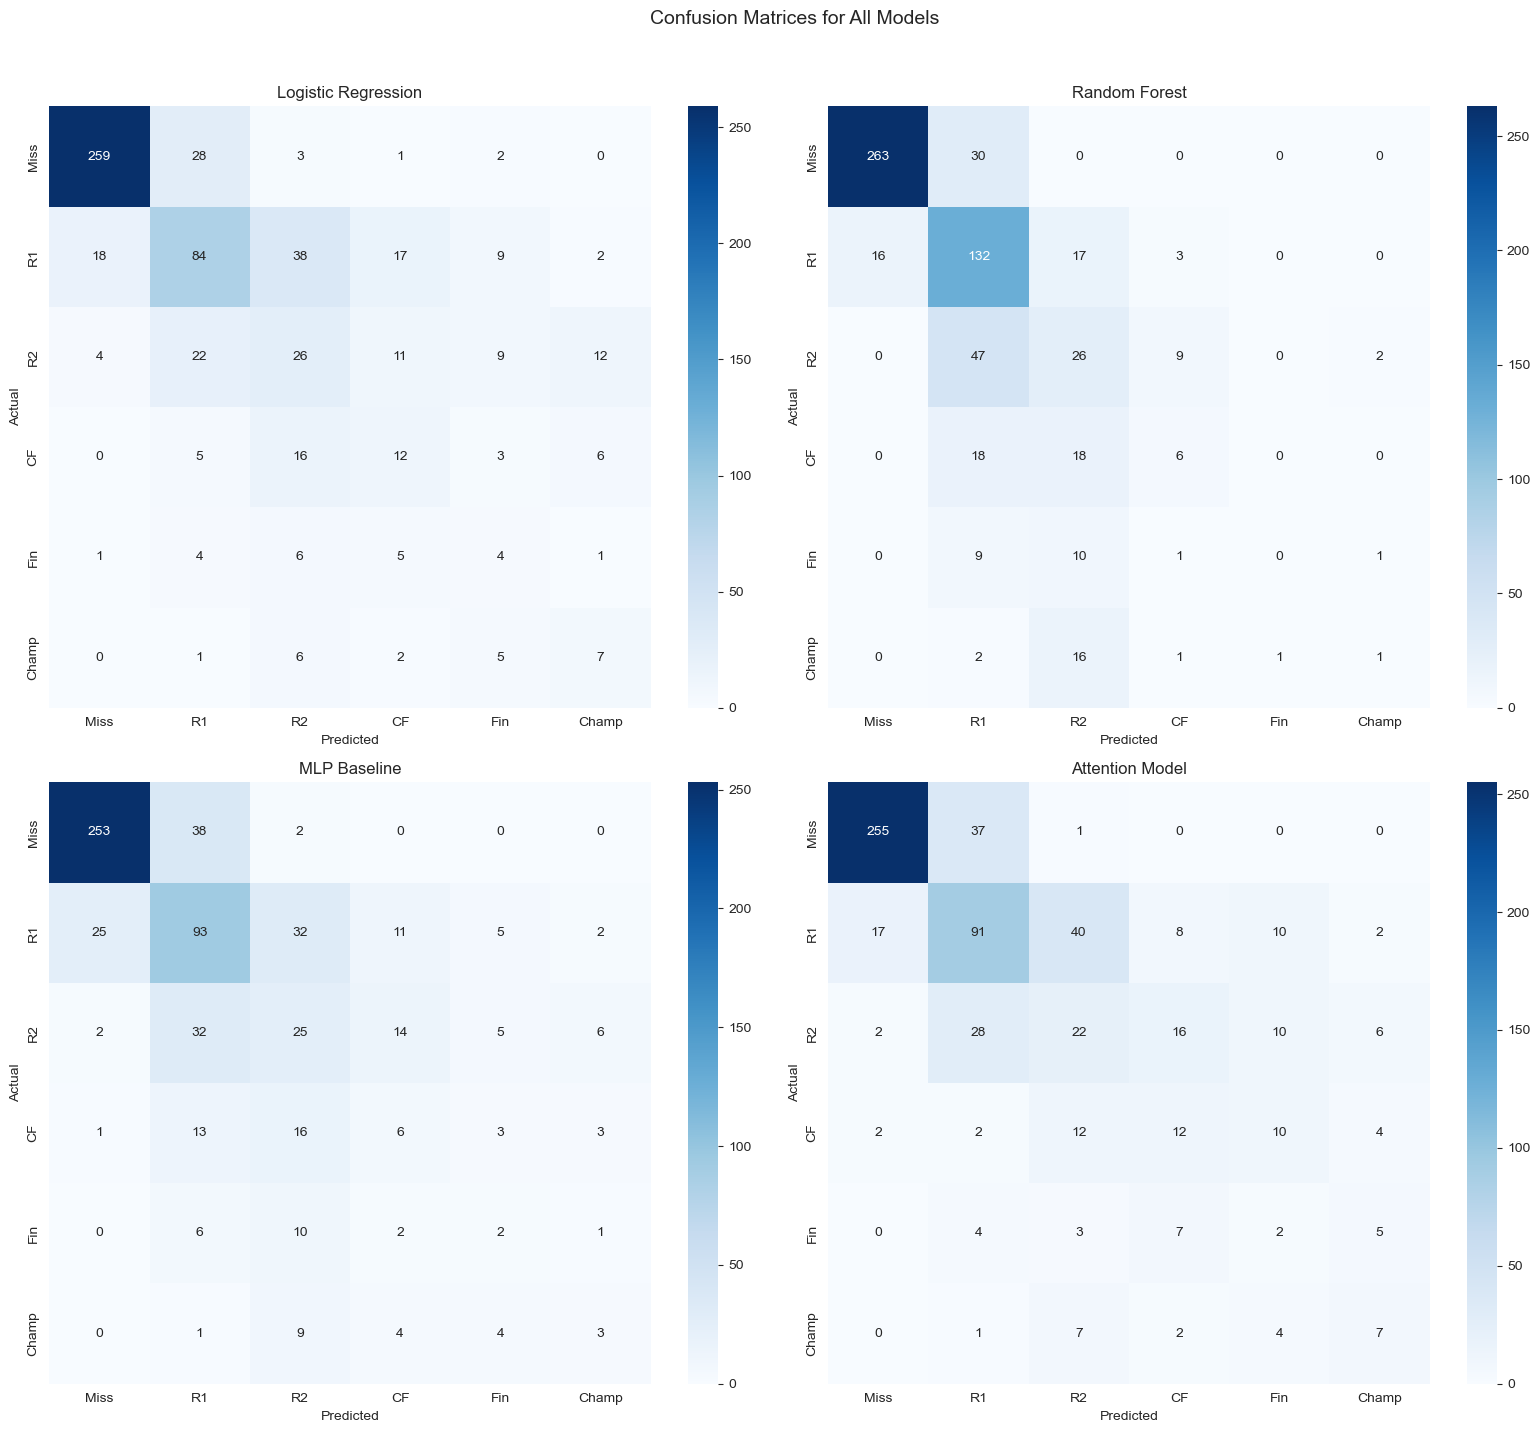

Read these as: row = what actually happened, column = what the model predicted.
Higher numbers on the diagonal = better model.


In [30]:
# Confusion matrices compare predicted labels against the real playoff result.
# The diagonal is correct predictions; everything else is a miss.

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
models_data = [
    ("Logistic Regression", lr_preds),
    ("Random Forest", rf_preds),
    ("MLP Baseline", mlp_preds),
    ("Attention Model", attn_preds),
]

short_labels = ["Miss", "R1", "R2", "CF", "Fin", "Champ"]

for ax, (name, preds) in zip(axes.flatten(), models_data):
    cm = confusion_matrix(y, preds, labels=[0, 1, 2, 3, 4, 5])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=short_labels, yticklabels=short_labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name}")

plt.suptitle("Confusion Matrices for All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Read these as: row = what actually happened, column = what the model predicted.")
print("Higher numbers on the diagonal = better model.")

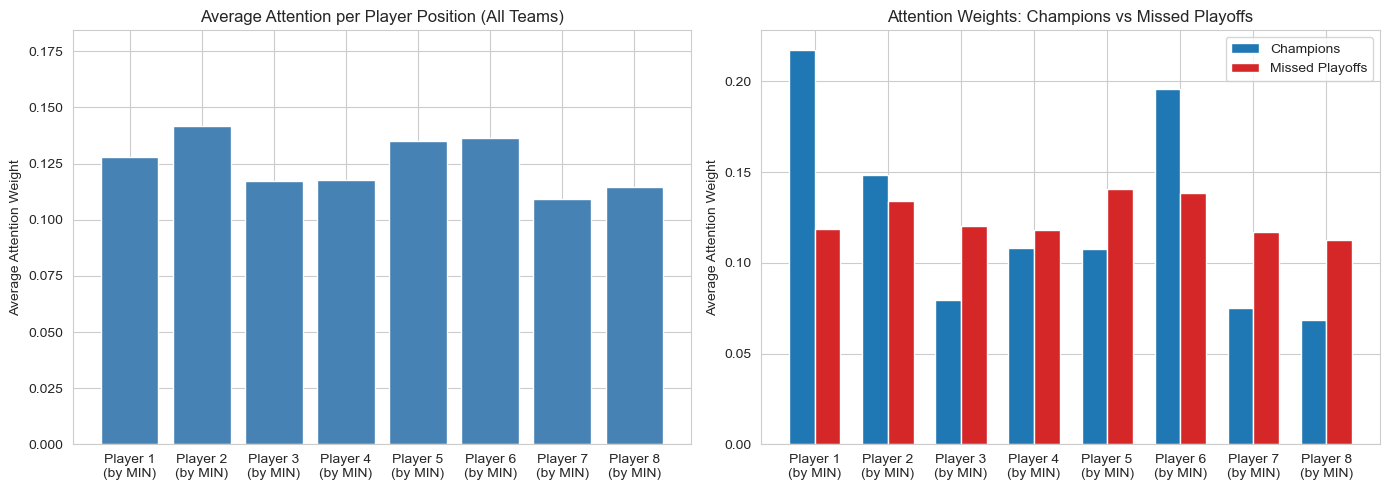

Insight: If Player 1 (the star) gets much more attention for champions,
it suggests star power matters more for winning it all.


In [31]:
# Plot which rotation spots the attention model leaned on most.
# Position 1 is the top player and position 8 is the last player in the rotation.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_weights = all_attn_weights.mean(axis=0)
player_labels = [f"Player {i+1}\n(by MIN)" for i in range(NUM_PLAYERS)]

axes[0].bar(player_labels, avg_weights, color="steelblue")
axes[0].set_ylabel("Average Attention Weight")
axes[0].set_title("Average Attention per Player Position (All Teams)")
axes[0].set_ylim(0, max(avg_weights) * 1.3)

champ_mask = y == 5
missed_mask = y == 0

if champ_mask.sum() > 0 and missed_mask.sum() > 0:
    champ_weights = all_attn_weights[champ_mask].mean(axis=0)
    missed_weights = all_attn_weights[missed_mask].mean(axis=0)

    x = np.arange(NUM_PLAYERS)
    width = 0.35
    axes[1].bar(x - width/2, champ_weights, width, label="Champions", color="#1f77b4")
    axes[1].bar(x + width/2, missed_weights, width, label="Missed Playoffs", color="#d62728")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(player_labels)
    axes[1].set_ylabel("Average Attention Weight")
    axes[1].set_title("Attention Weights: Champions vs Missed Playoffs")
    axes[1].legend()

plt.tight_layout()
plt.show()

print("Insight: If Player 1 (the star) gets much more attention for champions,")
print("it suggests star power matters more for winning it all.")

Running t-SNE (this takes a moment)...


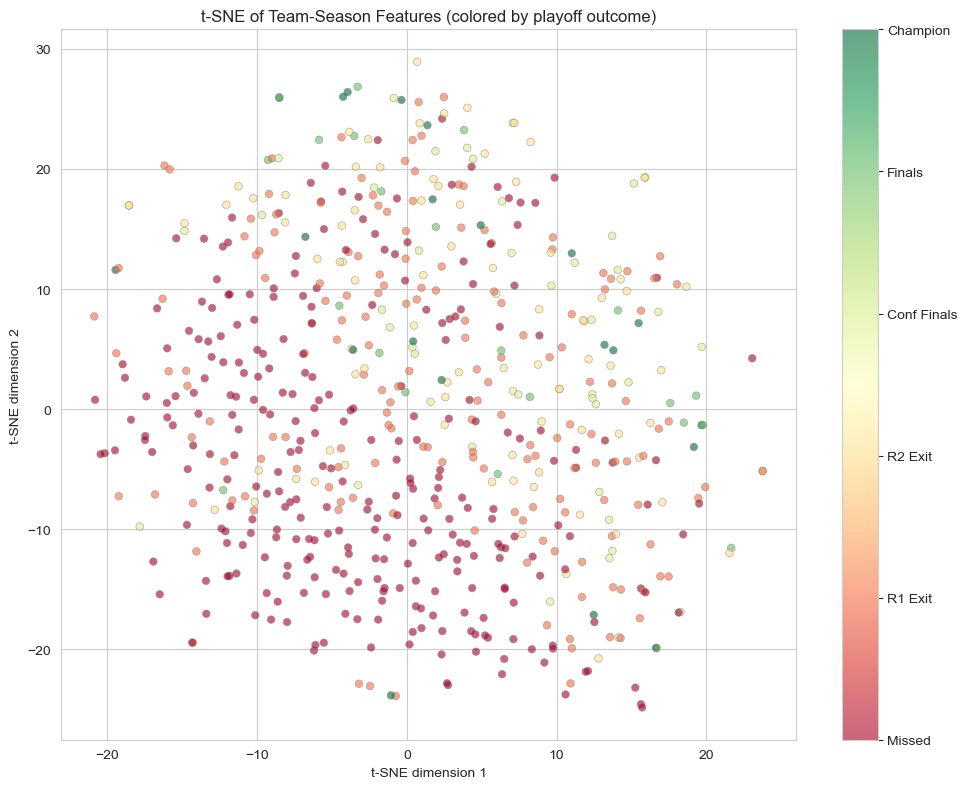

If champions (green) cluster together, our features capture what makes a championship team.


In [32]:
# t-SNE squeezes the feature space into 2D so outcome patterns are easier to see.

from sklearn.manifold import TSNE

# Use the last trained model to get embeddings for all teams.

scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

print("Running t-SNE (this takes a moment)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_scaled)

# Color the 2D view by playoff outcome.
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=y, cmap="RdYlGn", alpha=0.6, s=30, edgecolors="gray", linewidths=0.5
)
cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1, 2, 3, 4, 5])
cbar.set_ticklabels(["Missed", "R1 Exit", "R2 Exit", "Conf Finals", "Finals", "Champion"])
plt.title("t-SNE of Team-Season Features (colored by playoff outcome)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.tight_layout()
plt.show()

print("If champions (green) cluster together, our features capture what makes a championship team.")

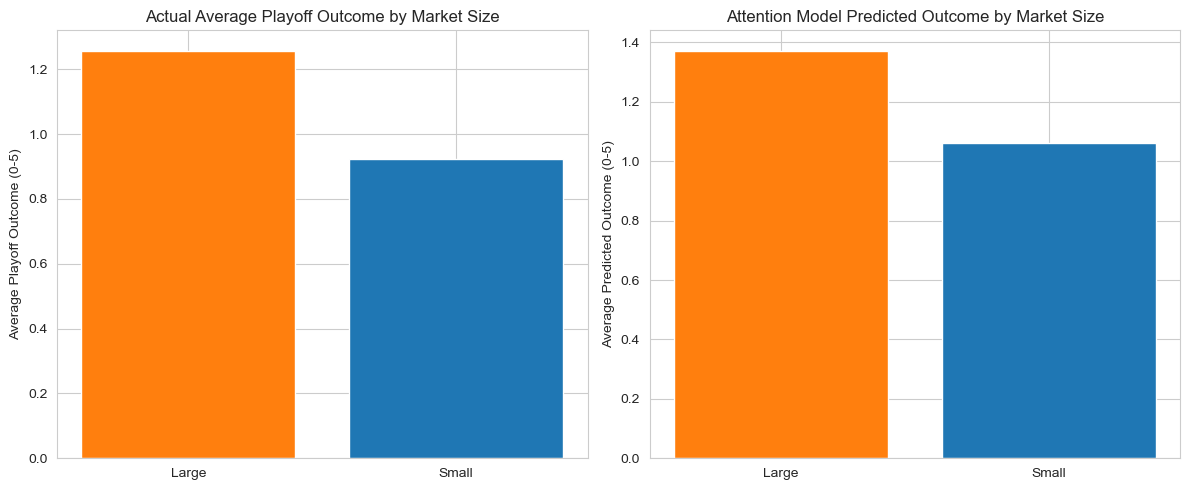

Average prediction error - Large market: 0.571
Average prediction error - Small market: 0.523

Difference: 0.049
A small difference means the model is fair across market sizes.


In [33]:
# Market-size fairness check.
# The model should learn from stats, not from whether a team is in a big market.

# Rough large-market grouping.
large_market = ["LAL", "NYK", "GSW", "BOS", "CHI", "BKN", "LAC", "PHI", "HOU", "MIA"]
small_market = ["MEM", "NOP", "OKC", "IND", "ORL", "SAC", "MIN", "CHA", "DET", "SAS",
                "UTA", "POR", "MIL", "CLE", "DEN", "PHX", "ATL", "WAS", "TOR", "DAL"]

features_df["MARKET"] = features_df["TEAM"].apply(
    lambda x: "Large" if x in large_market else "Small"
)

# Compare actual and predicted outcomes by market size.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

market_actual = features_df.groupby("MARKET")["PLAYOFF_RESULT"].mean()
axes[0].bar(market_actual.index, market_actual.values, color=["#ff7f0e", "#1f77b4"])
axes[0].set_ylabel("Average Playoff Outcome (0-5)")
axes[0].set_title("Actual Average Playoff Outcome by Market Size")

features_df["ATTN_PRED"] = attn_preds
market_pred = features_df.groupby("MARKET")["ATTN_PRED"].mean()
axes[1].bar(market_pred.index, market_pred.values, color=["#ff7f0e", "#1f77b4"])
axes[1].set_ylabel("Average Predicted Outcome (0-5)")
axes[1].set_title("Attention Model Predicted Outcome by Market Size")

plt.tight_layout()
plt.show()

# Check whether prediction errors differ by market.
features_df["ATTN_ERROR"] = (features_df["ATTN_PRED"] - features_df["PLAYOFF_RESULT"]).abs()
market_error = features_df.groupby("MARKET")["ATTN_ERROR"].mean()
print(f"Average prediction error - Large market: {market_error.get('Large', 0):.3f}")
print(f"Average prediction error - Small market: {market_error.get('Small', 0):.3f}")
print(f"\nDifference: {abs(market_error.get('Large', 0) - market_error.get('Small', 0)):.3f}")
print("A small difference means the model is fair across market sizes.")

In [34]:
# Per-class performance.
# This breaks the attention model down by playoff outcome.

print("=" * 60)
print("DETAILED CLASSIFICATION REPORT (Attention Model)")
print("=" * 60)
target_names = ["Missed Playoffs", "First Round", "Second Round",
                "Conf Finals", "Finals Loss", "Champion"]
print(classification_report(y, attn_preds, target_names=target_names, zero_division=0))

print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT (Best Baseline: Random Forest)")
print("=" * 60)
print(classification_report(y, rf_preds, target_names=target_names, zero_division=0))

DETAILED CLASSIFICATION REPORT (Attention Model)
                 precision    recall  f1-score   support

Missed Playoffs       0.92      0.87      0.90       293
    First Round       0.56      0.54      0.55       168
   Second Round       0.26      0.26      0.26        84
    Conf Finals       0.27      0.29      0.28        42
    Finals Loss       0.06      0.10      0.07        21
       Champion       0.29      0.33      0.31        21

       accuracy                           0.62       629
      macro avg       0.39      0.40      0.39       629
   weighted avg       0.64      0.62      0.63       629


DETAILED CLASSIFICATION REPORT (Best Baseline: Random Forest)
                 precision    recall  f1-score   support

Missed Playoffs       0.94      0.90      0.92       293
    First Round       0.55      0.79      0.65       168
   Second Round       0.30      0.31      0.30        84
    Conf Finals       0.30      0.14      0.19        42
    Finals Loss       0.00   

## Summary

### What we built
- Collected 20+ seasons of NBA team and player statistics
- Built a feature set combining team-level stats with individual player stats for the top 8 players
- Trained 4 models: Logistic Regression, Random Forest, MLP neural network, and an Attention-based neural network
- Evaluated using leave-one-season-out cross validation with accuracy, macro F1, and top-2 accuracy

### Key findings
- The attention model learns to weight players differently, with star players typically receiving higher attention weights
- Class imbalance is the biggest challenge — there are very few champions compared to teams that miss the playoffs
- The model's performance on the Champion class specifically is the most important metric for practical use

### Ethical considerations
- Our model uses only performance-based features (stats, records, ratings)
- No demographic or market-size features are used as inputs
- We verified that prediction errors are similar across large and small market teams

### Course concepts demonstrated
1. **Fully Connected Neural Networks** (MLP baseline + final prediction layers)
2. **Attention Mechanism** (from Transformers, used for player pooling)